### Pre Processing

In [2]:
import nibabel as nib
import numpy as np
import cv2
import SimpleITK as sitk
from skimage import exposure
import os

# ---------- config ----------
img_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
out_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1_preproc_clahe.nii.gz"
# If your 3D array has shape (slices, height, width), use SLICE_AXIS = 0
# If it has shape (height, width, slices) (rare for nibabel), use SLICE_AXIS = 2
SLICE_AXIS = 0
# CLAHE params
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)
# ----------------------------

# 1) load using nibabel (keep affine/header for saving)
img_nifti = nib.load(img_path)
affine = img_nifti.affine
header = img_nifti.header
img_data = img_nifti.get_fdata().astype(np.float32)  # float32 for processing

# Optionally reorder so slices are first axis: we want an array of shape (slices, H, W)
if SLICE_AXIS != 0:
    img_data = np.moveaxis(img_data, SLICE_AXIS, 0)

# 2) N4 Bias Field Correction (SimpleITK expects z,y,x numpy ordering -> OK)
sitk_img = sitk.GetImageFromArray(img_data)                       # float32
sitk_img = sitk.Cast(sitk_img, sitk.sitkFloat32)

# Create a crude mask to speed N4 and protect background (optional but recommended)
# Mask = voxels > tiny threshold
mask = sitk.GetImageFromArray((img_data > 0).astype(np.uint8))
mask = sitk.Cast(mask, sitk.sitkUInt8)

corrected_sitk = sitk.N4BiasFieldCorrection(sitk_img, mask)
img_corrected = sitk.GetArrayFromImage(corrected_sitk).astype(np.float32)

# (If we moved axes earlier, img_corrected already matches slices-first shape)

# 3) Z-score normalization — compute mean/std only over non-zero (brain) voxels
brain_mask = img_corrected > 0
if np.any(brain_mask):
    mean_val = img_corrected[brain_mask].mean()
    std_val = img_corrected[brain_mask].std()
else:
    # fallback to global stats if mask absent
    mean_val = img_corrected.mean()
    std_val = img_corrected.std()

if std_val == 0 or np.isnan(std_val):
    std_val = 1.0

img_norm = (img_corrected - mean_val) / std_val
# keep background as zero (or small negative). We'll re-mask later.

# 4) Contrast stretching using percentiles computed on brain voxels
if np.any(brain_mask):
    p2, p98 = np.percentile(img_norm[brain_mask], (2, 98))
else:
    p2, p98 = np.percentile(img_norm, (2, 98))

# Avoid degenerate percentile range
if p98 == p2:
    p2, p98 = img_norm.min(), img_norm.max()
    if p98 == p2:
        p2 -= 1.0
        p98 += 1.0

img_stretched = exposure.rescale_intensity(img_norm, in_range=(p2, p98), out_range=(0.0, 1.0))

# 5) Convert to uint8 (0-255) for CLAHE
img_uint8 = (img_stretched * 255.0).clip(0, 255).astype(np.uint8)

# 6) Apply CLAHE slice-wise (2D). CLAHE.apply requires single-channel uint8 images.
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
slices = img_uint8.shape[0]
clahe_slices = []
for i in range(slices):
    img_slice = img_uint8[i]            # shape (H, W)
    # If slice is all zero, CLAHE.apply will still work but has no effect; we can skip if desired
    if np.all(img_slice == 0):
        clahe_slices.append(img_slice)
    else:
        clahe_slices.append(clahe.apply(img_slice))

img_clahe = np.stack(clahe_slices, axis=0).astype(np.uint8)

# 7) Move axes back to original orientation if needed, and save
if SLICE_AXIS != 0:
    img_clahe = np.moveaxis(img_clahe, 0, SLICE_AXIS)

# Save as NIfTI using original affine and header (we use uint8 data)
out_img = nib.Nifti1Image(img_clahe, affine, header=header)
# Optionally set datatype in header
out_img.set_data_dtype(np.uint8)
nib.save(out_img, out_path)

print(f"Saved preprocessed image with CLAHE to: {out_path}")

Saved preprocessed image with CLAHE to: D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1_preproc_clahe.nii.gz


1. Load NIfTI image using Nibabel
2. Extract affine and header information
3. Convert image data to float32
4. Reorder axes so slices come first (if needed)
5. Create SimpleITK image from NumPy array
6. Generate binary mask for foreground voxels
7. Apply N4 bias field correction
8. Convert corrected image back to NumPy array
9. Create brain mask for nonzero voxels
10. Compute mean and standard deviation of brain voxels
11. Apply z-score normalization
12. Compute 2nd and 98th percentiles for contrast stretching
13. Rescale intensity to [0, 1] range
14. Convert image to uint8 (0–255 scale)
15. Initialize CLAHE with clip limit and tile size
16. Apply CLAHE slice-by-slice in 2D
17. Stack processed slices back into 3D array
18. Revert axes to original order (if changed)
19. Create NIfTI image with original affine and header
20. Save preprocessed image to output path


### Percentile Stretching -- Gamma -- CLAHE -- Unsharp Masking

In [1]:
import nibabel as nib
import numpy as np
import cv2
import SimpleITK as sitk
from skimage import exposure
import os
import datetime

# ---------- config ----------
img_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
out_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-49422_1997.02.22_t1_enhanced.nii.gz"

# If your 3D array has shape (slices, height, width), use SLICE_AXIS = 0
# If it has shape (height, width, slices) (rare for nibabel), use SLICE_AXIS = 2
SLICE_AXIS = 0

# CLAHE params (used for slice-wise CLAHE)
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)

# Choose enhancement pipeline: 'conservative' or 'aggressive'
ENHANCE_MODE = 'conservative'  # 'conservative' or 'aggressive'

# Use 3D unsharp (True) or 2D slice-wise unsharp (False)
USE_3D_UNSHARP = False

# Unsharp defaults (can be overridden depending on ENHANCE_MODE)
UNSHARP_SIGMA_2D = 1.0    # sigma in pixels for cv2.GaussianBlur when doing 2D unsharp
UNSHARP_AMOUNT_2D = 0.8   # weight for unsharp (0.5-1.0 typical)
UNSHARP_SIGMA_3D = 1.0    # sigma in mm/voxels for SimpleITK DiscreteGaussian when doing 3D unsharp
UNSHARP_AMOUNT_3D = 0.8

# Gamma defaults (will be adjusted by mode)
GAMMA = 0.9

# Misc
VERBOSE = True
# ----------------------------

# Mode-specific parameter adjustments
if ENHANCE_MODE == 'conservative':
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
    GAMMA = 0.95
    UNSHARP_SIGMA_2D = 0.8
    UNSHARP_AMOUNT_2D = 0.6
    UNSHARP_SIGMA_3D = 0.8
    UNSHARP_AMOUNT_3D = 0.6
elif ENHANCE_MODE == 'aggressive':
    CLAHE_CLIP = 3.5
    CLAHE_TILE = (8, 8)
    GAMMA = 0.85
    UNSHARP_SIGMA_2D = 1.2
    UNSHARP_AMOUNT_2D = 1.0
    UNSHARP_SIGMA_3D = 1.2
    UNSHARP_AMOUNT_3D = 1.0
else:
    print("Unknown ENHANCE_MODE; defaulting to conservative settings.")
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
    GAMMA = 0.95

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Starting preprocessing with ENHANCE_MODE={ENHANCE_MODE}, USE_3D_UNSHARP={USE_3D_UNSHARP}")

# ---------- 1) load using nibabel (keep affine/header for saving) ----------
img_nifti = nib.load(img_path)
affine = img_nifti.affine
header = img_nifti.header
img_data = img_nifti.get_fdata().astype(np.float32)  # float32 for processing

# Optionally reorder so slices are first axis: we want an array of shape (slices, H, W)
if SLICE_AXIS != 0:
    img_data = np.moveaxis(img_data, SLICE_AXIS, 0)

# ---------- 2) N4 Bias Field Correction ----------
# SimpleITK expects array shaped (z,y,x) which matches slices-first ordering
sitk_img = sitk.GetImageFromArray(img_data)                       # float32
sitk_img = sitk.Cast(sitk_img, sitk.sitkFloat32)

# Create a crude mask to speed N4 and protect background (optional but recommended)
mask_np = (img_data > 0).astype(np.uint8)
mask_sitk = sitk.GetImageFromArray(mask_np)
mask_sitk = sitk.Cast(mask_sitk, sitk.sitkUInt8)

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Running N4BiasFieldCorrection ... (this can take a while)")

corrected_sitk = sitk.N4BiasFieldCorrection(sitk_img, mask_sitk)
img_corrected = sitk.GetArrayFromImage(corrected_sitk).astype(np.float32)

# ---------- 3) Z-score normalization — compute mean/std only over non-zero (brain) voxels ----------
brain_mask = img_corrected > 0
if np.any(brain_mask):
    mean_val = img_corrected[brain_mask].mean()
    std_val = img_corrected[brain_mask].std()
else:
    mean_val = img_corrected.mean()
    std_val = img_corrected.std()

if std_val == 0 or np.isnan(std_val):
    std_val = 1.0

img_norm = (img_corrected - mean_val) / std_val

# Keep background zero
img_norm[~brain_mask] = 0.0

# ---------- 4) Contrast stretching using percentiles computed on brain voxels ----------
if np.any(brain_mask):
    p2, p98 = np.percentile(img_norm[brain_mask], (2, 98))
else:
    p2, p98 = np.percentile(img_norm, (2, 98))

# Avoid degenerate percentile range
if p98 == p2:
    p2, p98 = img_norm.min(), img_norm.max()
    if p98 == p2:
        p2 -= 1.0
        p98 += 1.0

img_stretched = exposure.rescale_intensity(img_norm, in_range=(p2, p98), out_range=(0.0, 1.0))
img_stretched[~brain_mask] = 0.0

# ---------- 5) Gamma correction (on brain voxels only) ----------
img_gamma = np.copy(img_stretched)
if np.any(brain_mask):
    img_gamma[brain_mask] = np.power(img_stretched[brain_mask], GAMMA)
else:
    img_gamma = np.power(img_stretched, GAMMA)
img_gamma[~brain_mask] = 0.0

# ---------- 6) Unsharp mask (2D slice-wise or 3D) ----------
if USE_3D_UNSHARP:
    # 3D unsharp using SimpleITK DiscreteGaussian smoothing
    if VERBOSE:
        print(f"[{datetime.datetime.now()}] Applying 3D unsharp (SimpleITK DiscreteGaussian) ...")
    # convert to sitk image
    sitk_float = sitk.GetImageFromArray(img_gamma)
    sitk_float = sitk.Cast(sitk_float, sitk.sitkFloat32)
    # apply DiscreteGaussian smoothing (sigma in voxel units)
    smoothed = sitk.DiscreteGaussian(sitk_float, variance=UNSHARP_SIGMA_3D**2)
    smoothed_np = sitk.GetArrayFromImage(smoothed).astype(np.float32)
    # unsharp: res = (1+amount)*orig - amount*smoothed
    img_unsharp = (1.0 + UNSHARP_AMOUNT_3D) * img_gamma - UNSHARP_AMOUNT_3D * smoothed_np
    img_unsharp = np.clip(img_unsharp, 0.0, 1.0)
    img_unsharp[~brain_mask] = 0.0
else:
    # 2D slice-wise unsharp using cv2 GaussianBlur on float slices
    if VERBOSE:
        print(f"[{datetime.datetime.now()}] Applying 2D slice-wise unsharp (cv2 GaussianBlur) ...")
    slices = img_gamma.shape[0]
    img_unsharp = np.zeros_like(img_gamma, dtype=np.float32)
    for i in range(slices):
        src = img_gamma[i]
        if np.all(src == 0):
            img_unsharp[i] = src
        else:
            # cv2.GaussianBlur supports float32; pass ksize=(0,0) to infer kernel from sigma
            blurred = cv2.GaussianBlur(src.astype(np.float32), ksize=(0, 0),
                                       sigmaX=UNSHARP_SIGMA_2D, sigmaY=UNSHARP_SIGMA_2D,
                                       borderType=cv2.BORDER_REPLICATE)
            res = cv2.addWeighted(src.astype(np.float32), 1.0 + UNSHARP_AMOUNT_2D, blurred, -UNSHARP_AMOUNT_2D, 0.0)
            res = np.clip(res, 0.0, 1.0)
            # Keep background zero
            if np.any(brain_mask[i] == False):
                res[np.logical_not(brain_mask[i])] = 0.0
            img_unsharp[i] = res

# ---------- 7) Convert to uint8 and apply CLAHE slice-wise ----------
if VERBOSE:
    print(f"[{datetime.datetime.now()}] Converting to uint8 and applying CLAHE (clip={CLAHE_CLIP}, tile={CLAHE_TILE}) ...")
img_uint8 = (img_unsharp * 255.0).clip(0, 255).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

slices = img_uint8.shape[0]
clahe_slices = []
for i in range(slices):
    img_slice = img_uint8[i]
    if np.all(img_slice == 0):
        clahe_slices.append(img_slice)
    else:
        # Optionally, you can restrict CLAHE to brain region by masking; here we apply to whole slice
        clahe_slice = clahe.apply(img_slice)
        # re-mask background to zero (avoid background enhancement/artifacts)
        if np.any(~brain_mask[i]):
            clahe_slice[np.logical_not(brain_mask[i])] = 0
        clahe_slices.append(clahe_slice)

img_clahe = np.stack(clahe_slices, axis=0).astype(np.uint8)

# ---------- 8) Move axes back to original orientation if needed, and save ----------
if SLICE_AXIS != 0:
    img_clahe = np.moveaxis(img_clahe, 0, SLICE_AXIS)

# Ensure output directory exists
out_dir = os.path.dirname(out_path)
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir, exist_ok=True)

# Save as NIfTI using original affine and header (we use uint8 data)
out_fname = out_path
# add mode tag to filename if not already present
base, ext = os.path.splitext(out_fname)
if ext == '.gz':
    base2, ext2 = os.path.splitext(base)
    ext = ext2 + ext
    base = base2
tag = f"_{ENHANCE_MODE}"
if USE_3D_UNSHARP:
    tag += "_3Dunsharp"
else:
    tag += "_2Dunsharp"
out_fname = base + tag + ext

out_img = nib.Nifti1Image(img_clahe, affine, header=header)
out_img.set_data_dtype(np.uint8)
nib.save(out_img, out_fname)

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Saved enhanced image to: {out_fname}")
    print(f"[{datetime.datetime.now()}] Done.")


[2025-10-21 23:00:58.783035] Starting preprocessing with ENHANCE_MODE=conservative, USE_3D_UNSHARP=False
[2025-10-21 23:01:00.347889] Running N4BiasFieldCorrection ... (this can take a while)
[2025-10-21 23:06:12.233213] Applying 2D slice-wise unsharp (cv2 GaussianBlur) ...
[2025-10-21 23:06:12.316956] Converting to uint8 and applying CLAHE (clip=2.0, tile=(8, 8)) ...
[2025-10-21 23:06:12.919003] Saved enhanced image to: D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz
[2025-10-21 23:06:12.919003] Done.


### Reference Mask

In [4]:
import numpy as np
import nibabel as nib
from scipy import ndimage as ndi

# --- File paths ---
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

# --- Load images ---
img_nifti = nib.load(img_path)
img = img_nifti.get_fdata().astype(np.float32)
affine = img_nifti.affine

tumor_mask_nifti = nib.load(tumor_mask_path)
tumor_mask = tumor_mask_nifti.get_fdata()
tumor_mask = (tumor_mask > 0)  # Convert multi-label to binary

# --- Create brain mask from image (simple threshold) ---
brain_mask = img > 0  # assuming nonzero voxels are brain

# --- 1. Find tumor centroid ---
coords = np.argwhere(tumor_mask)
if coords.size == 0:
    raise ValueError("Tumor mask is empty! Check your segmentation file.")
centroid = coords.mean(axis=0).astype(int)
print("Tumor centroid:", centroid)

# --- 2. Compute midline along left-right axis (last axis) ---
brain_coords = np.argwhere(brain_mask)
midline = brain_coords[:, -1].mean()
print("Midline x-coordinate:", midline)

# --- 3. Mirror centroid across midline ---
mirror_centroid = centroid.copy()
mirror_centroid[-1] = int(midline - (centroid[-1] - midline))
print("Reference region centroid:", mirror_centroid)

# --- 4. Create small cube around mirror_centroid ---
radius = 5  # voxels
ref_mask = np.zeros_like(tumor_mask, dtype=bool)
mins = np.maximum(mirror_centroid - radius, 0)
maxs = np.minimum(mirror_centroid + radius + 1, np.array(tumor_mask.shape))
ref_mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]] = True

# --- 5. Restrict to brain ---
ref_mask = np.logical_and(ref_mask, brain_mask)

# # --- Optional: save reference mask ---
# nib.save(nib.Nifti1Image(ref_mask.astype(np.uint8), affine), 
#          r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-4942_refMask.nii.gz")

# print("Reference mask created and saved.")


Tumor centroid: [ 87 119  76]
Midline x-coordinate: 71.8253934929086
Reference region centroid: [ 87 119  67]


### Noise Mask

In [5]:
# 1. Invert brain mask
inv_brain = np.logical_not(brain_mask)

# 2. Use distance transform to pick a voxel farthest from brain (deepest air)
dt = ndi.distance_transform_edt(inv_brain)
maxpos = np.unravel_index(np.argmax(dt), dt.shape)

# 3. Create small cuboid around that voxel
radius = 5
noise_mask = np.zeros_like(tumor_mask, dtype=bool)
mins = np.maximum(np.array(maxpos) - radius, 0)
maxs = np.minimum(np.array(maxpos) + radius + 1, np.array(tumor_mask.shape))
noise_mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]] = True


✅ Significance of this reference mask:

This is not tumor.

It represents the same approximate location in the opposite hemisphere.

Useful for:

Comparing tumor vs normal tissue intensity or texture.

Feature extraction (e.g., difference between tumor and healthy mirror region).

This is exactly why the green contour is plotted in your visualization: it shows the reference region opposite to the tumor.

Image shape: (240, 240, 155)
Tumor mask shape: (240, 240, 155)
Reference mask shape: (240, 240, 155)
Visualizing axial slice: 77


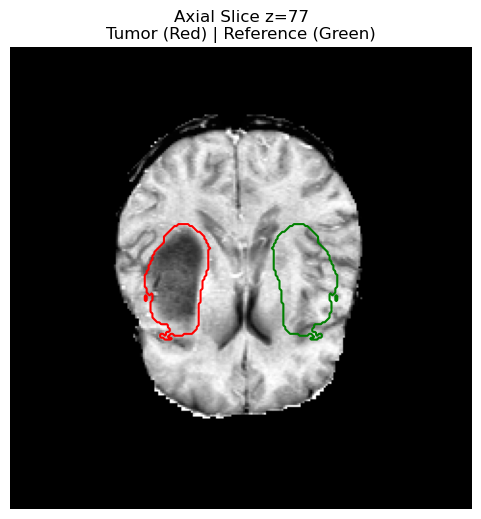

In [23]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---- Load MRI and tumor mask ----
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0  # convert to binary mask

# ---- Assume ref_mask is already in memory ----
# Example:
# ref_mask = np.load(r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-4942_refMask.npy")
# OR from your earlier code, you already created it:
# ref_mask = <your array>

# Sanity check
print("Image shape:", data.shape)
print("Tumor mask shape:", tumor_mask.shape)
print("Reference mask shape:", ref_mask.shape)

# ---- Pick an axial slice (z-direction) ----
z = data.shape[2] // 2  # center slice
print("Visualizing axial slice:", z)

# ---- Extract 2D slices ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Visualization ----
plt.figure(figsize=(6, 6))
plt.imshow(img_slice, cmap='gray', origin='upper')

# Option 1: Contour outlines (clean look)
plt.contour(tumor_slice, levels=[0.5], colors='r', linewidths=1.5)
plt.contour(ref_slice, levels=[0.5], colors='g', linewidths=1.5)

# Option 2 (optional): Transparent overlays — comment out if not needed
# plt.imshow(np.ma.masked_where(~tumor_slice, tumor_slice), cmap='Reds', alpha=0.4)
# plt.imshow(np.ma.masked_where(~ref_slice, ref_slice), cmap='Greens', alpha=0.4)

plt.title(f"Axial Slice z={z}\nTumor (Red) | Reference (Green)")
plt.axis('off')
plt.show()


Image shape: (240, 240, 155)
Tumor mask shape: (240, 240, 155)
Reference mask shape: (240, 240, 155)
Visualizing axial slice with max tumor voxels at z = 76


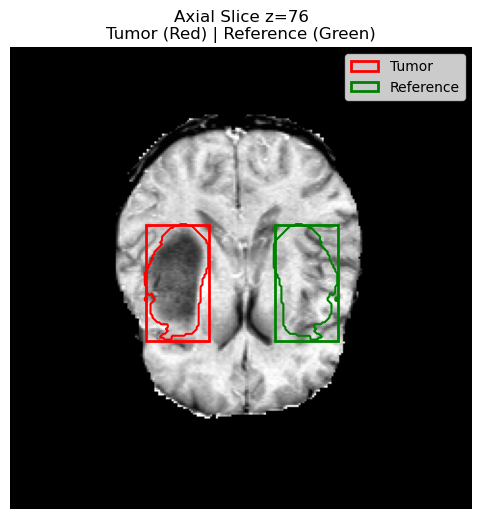

In [22]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- Load MRI and tumor mask ----
img_path =r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

# Load data
img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0

# ---- Generate reference mask by mirroring tumor mask ----
ref_mask = np.flip(tumor_mask, axis=0)  # mirror along left-right axis

# ---- Sanity check ----
print("Image shape:", data.shape)
print("Tumor mask shape:", tumor_mask.shape)
print("Reference mask shape:", ref_mask.shape)

# ---- Choose slice with maximum tumor voxels ----
tumor_counts = tumor_mask.sum(axis=(0, 1))
z = int(np.argmax(tumor_counts))
print("Visualizing axial slice with max tumor voxels at z =", z)

# ---- Extract 2D slices and rotate for display ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Bounding box helper ----
def bbox_from_mask2d(mask2d):
    coords = np.argwhere(mask2d)
    if coords.size == 0:
        return None
    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)
    return (rmin, cmin, rmax, cmax)

# ---- Compute bounding boxes ----
tumor_bb = bbox_from_mask2d(tumor_slice)
ref_bb = bbox_from_mask2d(ref_slice)

# ---- Visualization ----
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_slice, cmap='gray', origin='upper')

# Contour outlines
if tumor_slice.sum() > 0:
    ax.contour(tumor_slice, levels=[0.5], colors='r', linewidths=1.5)
if ref_slice.sum() > 0:
    ax.contour(ref_slice, levels=[0.5], colors='g', linewidths=1.5)

# Bounding boxes
if tumor_bb is not None:
    rmin, cmin, rmax, cmax = tumor_bb
    ax.add_patch(patches.Rectangle((cmin, rmin), cmax - cmin + 1, rmax - rmin + 1,
                                   linewidth=2, edgecolor='r', facecolor='none', label='Tumor'))

if ref_bb is not None:
    rmin, cmin, rmax, cmax = ref_bb
    ax.add_patch(patches.Rectangle((cmin, rmin), cmax - cmin + 1, rmax - rmin + 1,
                                   linewidth=2, edgecolor='g', facecolor='none', label='Reference'))

# Final touches
ax.set_title(f"Axial Slice z={z}\nTumor (Red) | Reference (Green)")
ax.axis('off')
ax.legend(loc='upper right')
plt.show()


### Segmentation

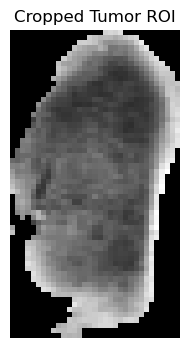


--- Tumor ROI Intensity Features ---
Pixel Count       : 1409
Mean Intensity    : 117.87
Std Dev Intensity : 49.89
Skewness          : 0.78
Kurtosis          : -0.45
✅ Saved segmented tumor as 3D NIfTI: tumor_roi_3D_volume.nii.gz


In [36]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import skew, kurtosis
import os

# ---- Load MRI and tumor mask ----
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0

# ---- Mirror tumor mask to create reference ----
ref_mask = np.flip(tumor_mask, axis=0)

# ---- Choose slice with max tumor voxels ----
tumor_counts = tumor_mask.sum(axis=(0, 1))
z = int(np.argmax(tumor_counts))

# ---- Extract and rotate slices ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Bounding box helper ----
def bbox_from_mask2d(mask2d):
    coords = np.argwhere(mask2d)
    if coords.size == 0:
        return None
    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)
    return (rmin, cmin, rmax, cmax)

tumor_bb = bbox_from_mask2d(tumor_slice)

# ---- Segment tumor ROI ----
tumor_roi = img_slice * tumor_slice  # apply mask

if tumor_bb is not None:
    rmin, cmin, rmax, cmax = tumor_bb
    cropped_roi = tumor_roi[rmin:rmax+1, cmin:cmax+1]
else:
    cropped_roi = None

# ---- Visualize segmented ROI ----
if cropped_roi is not None:
    plt.figure(figsize=(4, 4))
    plt.imshow(cropped_roi, cmap='gray', interpolation='none')
    plt.title("Cropped Tumor ROI")
    plt.axis('off')
    plt.show()

# ---- Extract intensity features ----
if cropped_roi is not None and np.any(cropped_roi):
    roi_pixels = cropped_roi[cropped_roi > 0]
    mean_intensity = np.mean(roi_pixels)
    std_intensity = np.std(roi_pixels)
    skewness = skew(roi_pixels)
    kurt = kurtosis(roi_pixels)
    pixel_count = roi_pixels.size

    print("\n--- Tumor ROI Intensity Features ---")
    print(f"Pixel Count       : {pixel_count}")
    print(f"Mean Intensity    : {mean_intensity:.2f}")
    print(f"Std Dev Intensity : {std_intensity:.2f}")
    print(f"Skewness          : {skewness:.2f}")
    print(f"Kurtosis          : {kurt:.2f}")
else:
    print("No valid tumor ROI found for feature extraction.")

# ---- Save segmented tumor as 3D NIfTI ----
output_dir = r"D:\MI_BRATS\Output_Features"
os.makedirs(output_dir, exist_ok=True)

if cropped_roi is not None and np.any(cropped_roi):
    # Create a 3D volume with tumor ROI only in slice z
    tumor_3d = np.zeros_like(data, dtype=np.float32)
    tumor_3d[:, :, z] = tumor_mask[:, :, z] * data[:, :, z]  # apply mask to original slice

    # Save as 3D NIfTI
    tumor_3d_nifti = nib.Nifti1Image(tumor_3d, affine=img.affine)
    nib.save(tumor_3d_nifti, os.path.join(output_dir, "tumor_roi_3D_volume.nii.gz"))
    print("✅ Saved segmented tumor as 3D NIfTI: tumor_roi_3D_volume.nii.gz")


### Save the segmented tumor region in 3D as Nifti

In [41]:
# ---- Apply full 3D tumor mask to original image ----
tumor_3d = data * tumor_mask.astype(np.float32)

# ---- Save as 3D NIfTI ----
tumor_3d_nifti = nib.Nifti1Image(tumor_3d, affine=img.affine)
nib.save(tumor_3d_nifti, os.path.join(output_dir, "tumor_roi_full_3D_volume.nii.gz"))
print("✅ Saved full 3D tumor ROI volume with original intensities.")


✅ Saved full 3D tumor ROI volume with original intensities.


### last step -- on the segmented image --- SOMETHING IS WRONG

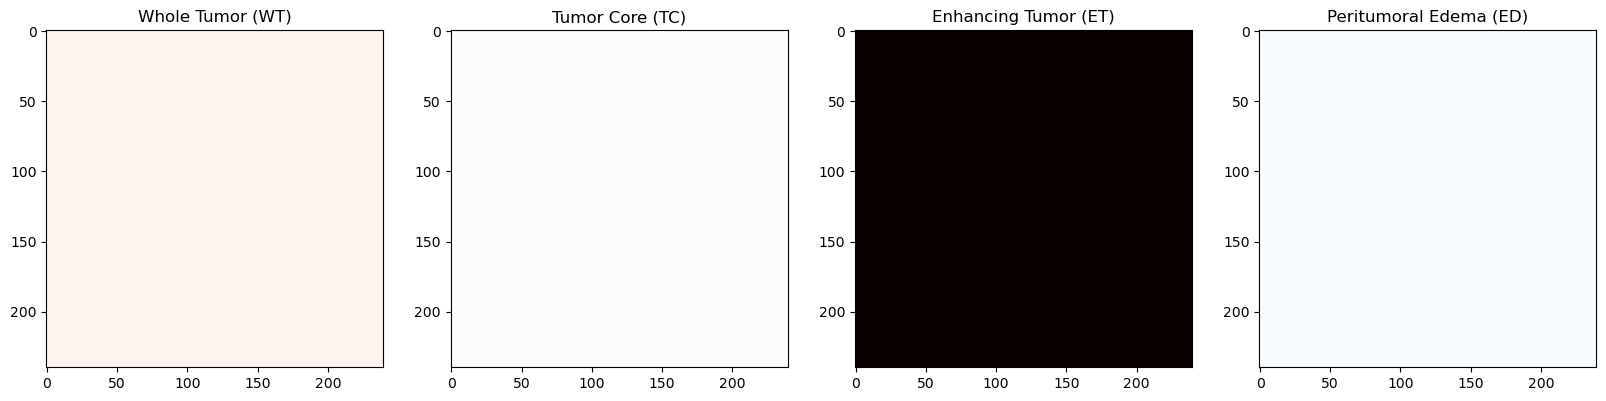

Enhancing Tumor Volume: 0.00 cm³


In [44]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---- Load the segmentation file ----
seg_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"  # replace with your file path
seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()

# ---- Extract tumor regions ----
enhancing_tumor = (seg_data == 4).astype(np.uint8)   # Enhancing Tumor
tumor_core = np.logical_or(seg_data == 1, seg_data == 4).astype(np.uint8)  # Core = 1 + 4
whole_tumor = np.logical_or.reduce((seg_data == 1, seg_data == 2, seg_data == 4)).astype(np.uint8)
edema = (seg_data == 2).astype(np.uint8)

# ---- Visualize a middle slice ----
slice_idx = seg_data.shape[2] // 2

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(whole_tumor[:, :, slice_idx], cmap='Reds')
axs[0].set_title("Whole Tumor (WT)")
axs[1].imshow(tumor_core[:, :, slice_idx], cmap='Purples')
axs[1].set_title("Tumor Core (TC)")
axs[2].imshow(enhancing_tumor[:, :, slice_idx], cmap='hot')
axs[2].set_title("Enhancing Tumor (ET)")
axs[3].imshow(edema[:, :, slice_idx], cmap='Blues')
axs[3].set_title("Peritumoral Edema (ED)")
plt.show()


voxel_volume = np.prod(seg_img.header.get_zooms())  # mm³ per voxel
et_volume = np.sum(enhancing_tumor) * voxel_volume / 1000  # cm³
print(f"Enhancing Tumor Volume: {et_volume:.2f} cm³")